# The problem with small datasets

In biomedical applications, it is common to encounter datasets with a limited number of samples. In these cases, developing general models for classification (or regression) is difficult because a small dataset often cannot capture the underlying structure of the data.

That said, it is often desired to use these small datasets as a proof of principle to justify the acquisition of additional data. 

There is no simple answer to what constitutes a *SMALL* dataset. According to sklearn, anything with less than 50 samples per class is considered a small dataset 😨.

This issue becomes more complex when a single subject provides multiple samples. In that case, a dataset with fewer than 50 subjects per class should be considered small. 

## How to deal with small datasets

In this notebook, we will work with a small dataset to obtain results that are not overconfident. It is **VERY** important to understand that these models are not general, and their main role is to motivate you to acquire more data...

The data was obtained from the following study:

>Silvi Frenkel-Toledo, Nir Giladi, Chava Peretz, Talia Herman, Leor Gruendlinger, Jeffrey M. Hausdorff  (2005, May). Treadmill walking as an external pacemaker to improve gait rhythm and stability in Parkinson's disease. Movement Disorders, Volume 20, Issue 9 pp. 1109-1114

In the study, 36 persons with Parkinson's disease and 30 controls walked on level ground, unassisted, for 2 minutes. Participants walked at self-selected speed wearing instrumented insoles. The insoles have 8 force sensors, and the data includes measures of each sensor (16 channels) and an average for each foot (2 additional channels). 

Multiple other studies use the same sensors in PD during different experiments. The data was compiled here: https://physionet.org/content/gaitpdb/1.0.0/

### What we will do 

In this notebook, we will use the force data to estimate gait parameters. Those gait parameters will then be used to train a classifier to detect healthy vs. Parkinson's disease. We will only compute a few measures for educational purposes; many other parameters could be derived from this dataset. 

We will:
- Inspect the data
- Develop an algorithm to extract gait metrics from force data
- Train and evaluate a model with a small dataset
- Explore the issues with small datasets


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
#to start, we can load a sample of the dataset and take a peek at the data
columns = [
    "time",
    "L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8",
    "R1", "R2", "R3", "R4", "R5", "R6", "R7", "R8",
    "L_total", "R_total"
]

sample_file = "data/SiCo01_01.txt"
df = pd.read_csv(sample_file, sep=r"\s+|\t+", engine="python", header=None, names=columns)


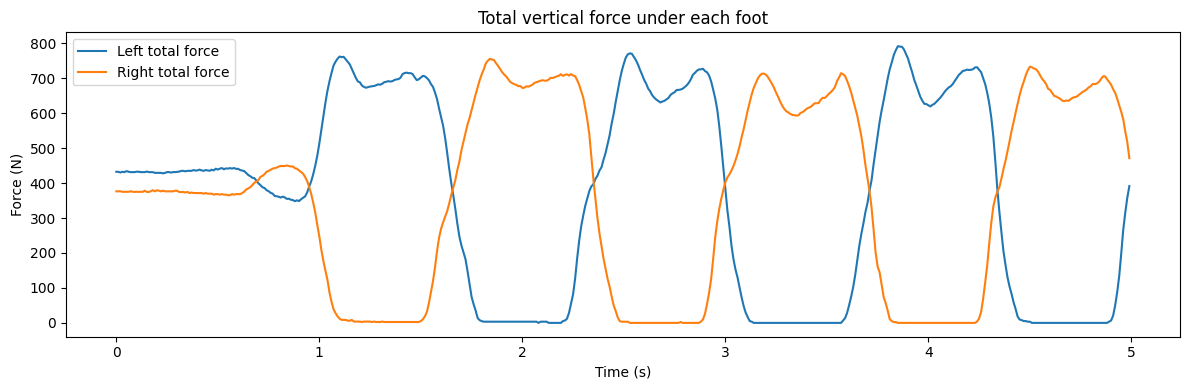

In [4]:
#plot the total force for left and right foot
plt.figure(figsize=(12, 4))
plt.plot(df["time"][0:500], df["L_total"][0:500], label="Left total force")
plt.plot(df["time"][0:500], df["R_total"][0:500], label="Right total force")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title("Total vertical force under each foot")
plt.legend()
plt.tight_layout()
plt.show()

### What can we do with this data? 

The goal is to extract gait information that allows us to compute relevant gait parameters, such as 
- Stance time
- Swing time
- Step time
- Cadence

<div style="text-align:center;">
    <img src="images/gaitcyle.jpg" 
    style="max-width:80%; height:auto;">
</div>


We can clearly see that the force indicates when the foot leaves the floor (toe-off) and when the foot hits the floor again (heel-strike). This information can be easily extracted from the signal using a threshold. We can try multiple thresholds and see what works best. 

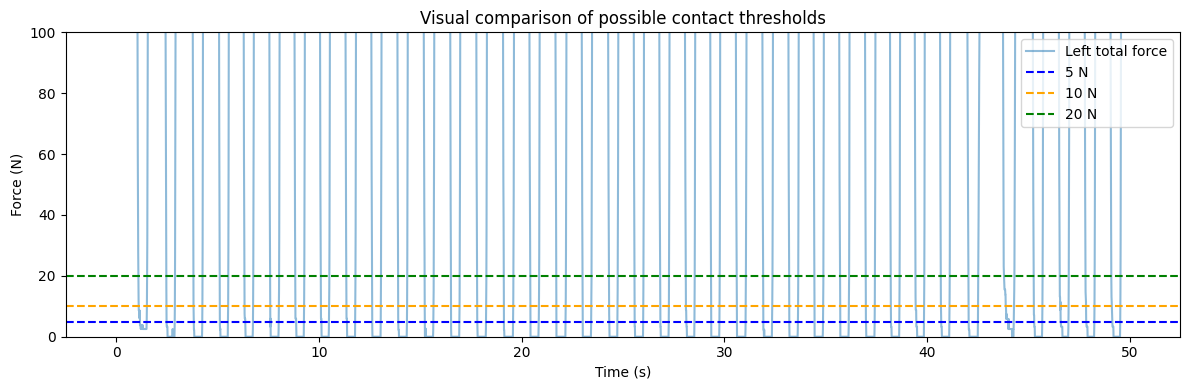

In [26]:
#lest visualize the threshold for foot contact detection
plt.figure(figsize=(12, 4))
plt.plot(df["time"][0:5000], df["R_total"][0:5000], alpha=0.5, label="Left total force")
colors = ["blue",'orange', 'green']
for i, thr in enumerate([5, 10, 20]):
    plt.axhline(thr, linestyle="--", color=colors[i], label=f"{thr} N")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title("Visual comparison of possible contact thresholds")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Thresholds:

- 5 N -> Too close to 0, it might be affected by noise
- 20 N -> Too far away from 0, timing detection might be biased
- 10 N -> Appears to provide a good balance. Will use this threshold to detect when the foot is in the ground.

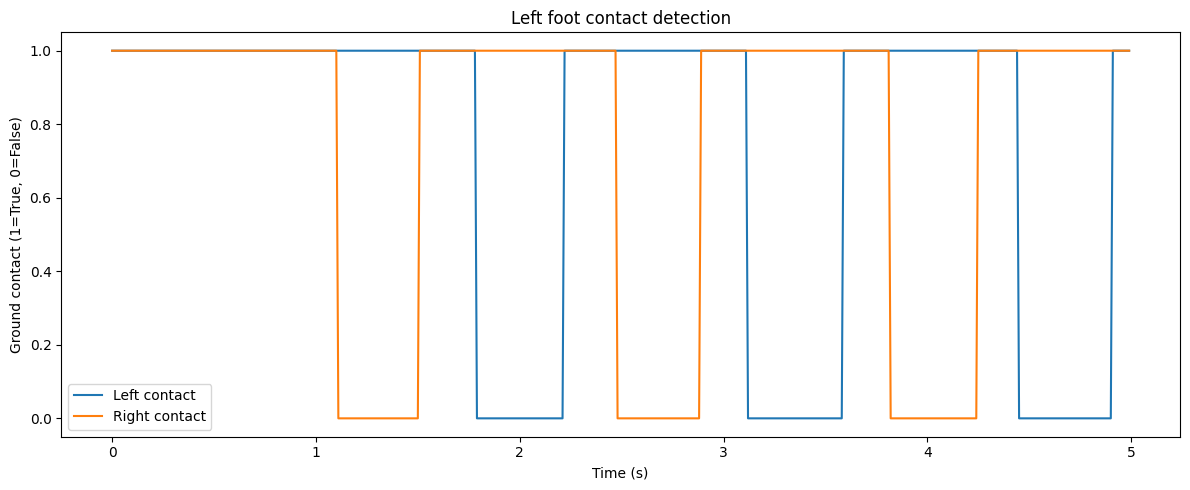

In [16]:
#define the threshold for foot contact detection
threshold = 20.0

#get the time points where the total force exceeds the threshold for left and right foot
left_contact = (df["L_total"].values > threshold).astype(int)
right_contact = (df["R_total"].values > threshold).astype(int)

plt.figure(figsize=(12, 5))
plt.plot(df["time"][0:500], left_contact[0:500],label="Left contact")
plt.plot(df["time"][0:500], right_contact[0:500],label="Right contact")
plt.xlabel("Time (s)")
plt.ylabel("Ground contact (1=True, 0=False)")
plt.title("Left foot contact detection")
plt.legend()
plt.tight_layout()
plt.show()

As we can see, when the foot hits the ground, the signal moves from 0 to 1. And when the foot leaves the ground, the signal moves from 1 to 0. We can detect these events by finding the difference between consecutive data points in the signal

There are numpy functions that can help us with this, including `n.diff()` and `np.where()`

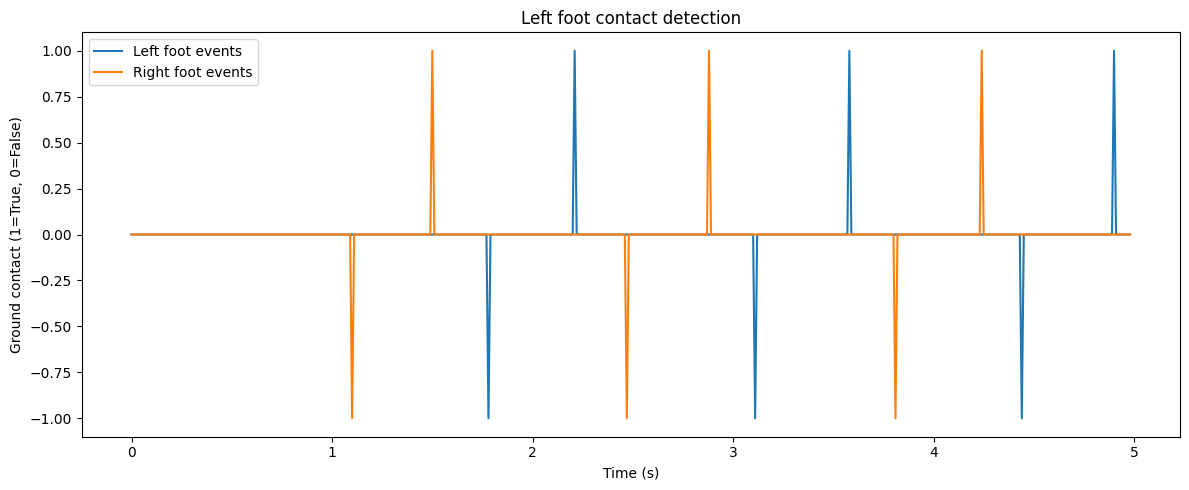

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df["time"][0:499], np.diff(left_contact[0:500]),label="Left foot events")
plt.plot(df["time"][0:499], np.diff(right_contact[0:500]),label="Right foot events")
plt.xlabel("Time (s)")
plt.ylabel("Ground contact (1=True, 0=False)")
plt.title("Left foot contact detection")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
heel_strikes_left = np.where(np.diff(left_contact)==1)[0]
toe_offs_left = np.where(np.diff(left_contact)==-1)[0]

heel_strikes_right = np.where(np.diff(right_contact)==1)[0]
toe_offs_right = np.where(np.diff(right_contact)==-1)[0]


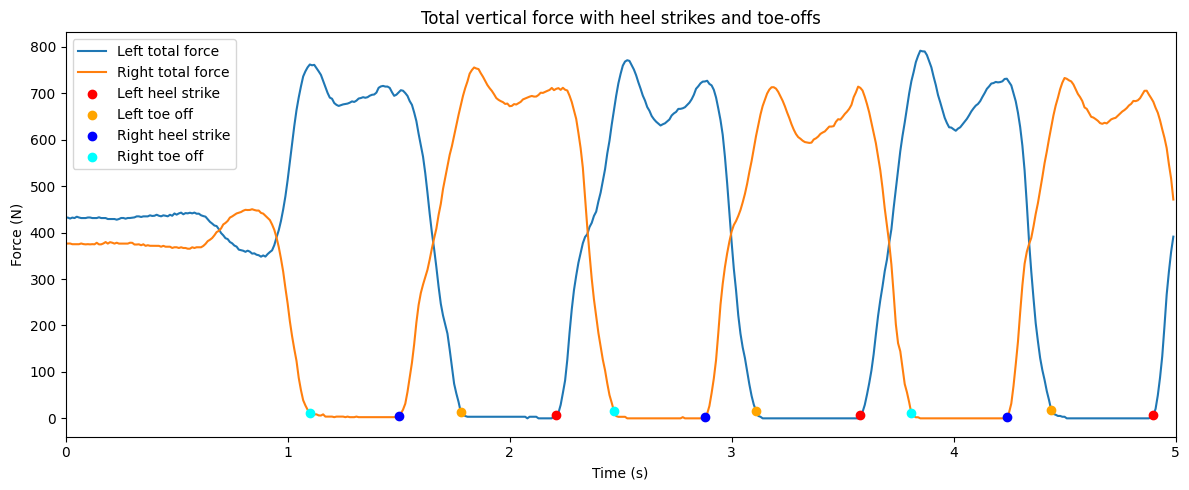

In [23]:
#lest check out estimation with some plots :) 
#plot the total force with heel strikes and toe-offs marked
plt.figure(figsize=(12, 5))
plt.plot(df["time"][0:500], df["L_total"][0:500], label="Left total force")
plt.plot(df["time"][0:500], df["R_total"][0:500], label="Right total force")
plt.scatter(df["time"].values[heel_strikes_left], df["L_total"].values[heel_strikes_left], color="red", label="Left heel strike", zorder=5)
plt.scatter(df["time"].values[toe_offs_left], df["L_total"].values[toe_offs_left], color="orange", label="Left toe off", zorder=5)
plt.scatter(df["time"].values[heel_strikes_right], df["R_total"].values[heel_strikes_right], color="blue", label="Right heel strike", zorder=5)
plt.scatter(df["time"].values[toe_offs_right], df["R_total"].values[toe_offs_right], color="cyan", label="Right toe off", zorder=5)
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title("Total vertical force with heel strikes and toe-offs")
plt.xlim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()

Now we can estimate different measures:

Stride time = Time between heel strikes 